# Amazon Sales & Customer Behavior Analysis: Exploratory Data Analysis Using Python

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
df = pd.read_csv("amazon_india_orders.csv")

In [3]:
df = pd.read_csv("amazon_india_orders.csv")

In [4]:
df.head()

,order_id,order_date,customer_id,customer_name,email,phone,city,state,pincode,asin,...,gst_amount,payment_method,prime_member,shipping_method,ship_date,delivery_date,order_status,product_rating,review_count,return_eligible
0,404-9360109-6942026,2023-05-02,CUST418506,Rajni Jain,rajni.jain_237@outlook.com,7357924695,Gaya,Bihar,823001,B04L82PE4V,...,1319.88,UPI,No,Same Day,2023-05-05,2023-05-12,Delivered,5.0,3381,No
1,404-3914837-1072424,2021-11-05,CUST817303,Varun Singh,varun.singh@gmail.com,7919890918,Dwarka,Delhi,110075,B0CE36WDSI,...,1399.72,Credit Card,No,Standard,2021-11-07,2021-11-14,Delivered,4.0,4319,No
2,404-4526124-4487235,2024-08-13,CUST100486,Nidhi Yadav,nidhi.yadav@yahoo.co.in,7054472576,Ahmedabad,Gujarat,380001,B0LST65XFV,...,5599.44,Credit Card,No,Standard,2024-08-14,2024-08-19,Delivered,4.2,3559,No
3,404-2598402-1912337,2024-09-12,CUST267787,Shalini Bhatt,shalini.bhatt69@rediffmail.com,6463468254,Ahmedabad,Gujarat,380001,B0I2MPQL8Y,...,2749.95,UPI,No,Standard,2024-09-14,NaN,Shipped,3.1,1770,No
4,404-4083969-9049218,2023-01-18,CUST330953,Kavya Das,kavya.das@rediffmail.com,8284382683,Faridabad,Haryana,121001,B0Y9MLZT1A,...,7019.46,Net Banking,No,Amazon Fresh,NaN,NaN,Cancelled,3.1,3126,Yes


In [5]:
df.tail(3)

,order_id,order_date,customer_id,customer_name,email,phone,city,state,pincode,asin,...,gst_amount,payment_method,prime_member,shipping_method,ship_date,delivery_date,order_status,product_rating,review_count,return_eligible
9997,404-4572583-7650355,2024-05-13,CUST283324,Nikhil Pillai,nikhil.pillai73@rediffmail.com,9365920114,Jaipur,Rajasthan,302001,B00SJS15XI,...,10499.75,Net Banking,Yes,Same Day,2024-05-16,2024-05-20,Delivered,4.7,8362,No
9998,404-9332903-4014552,2024-01-05,CUST252877,Sara Nair,sara.nair86@outlook.com,6742960591,Faridabad,Haryana,121001,B0IBS3IIC9,...,11198.60,UPI,Yes,Standard,NaN,NaN,Cancelled,4.6,4797,Yes
9999,404-9984840-1686054,2022-09-14,CUST529790,Lakshmi Choudhary,lakshmi.choudhary@rediffmail.com,7431107698,Ahmedabad,Gujarat,380001,B0JFNOPQJ4,...,12239.64,Cash on Delivery,No,Free Shipping,2022-09-17,2022-09-24,Delivered,3.9,246,No


In [6]:
df.info

<bound method DataFrame.info of                  order_id  order_date customer_id      customer_name  \
0     404-9360109-6942026  2023-05-02  CUST418506         Rajni Jain   
1     404-3914837-1072424  2021-11-05  CUST817303        Varun Singh   
2     404-4526124-4487235  2024-08-13  CUST100486        Nidhi Yadav   
3     404-2598402-1912337  2024-09-12  CUST267787      Shalini Bhatt   
4     404-4083969-9049218  2023-01-18  CUST330953          Kavya Das   
...                   ...         ...         ...                ...   
9995  404-3677572-5130099  2021-02-26  CUST348214      Farhan Sharma   
9996  404-9640089-7047447  2023-02-04  CUST142073      Sanjay Tiwari   
9997  404-4572583-7650355  2024-05-13  CUST283324      Nikhil Pillai   
9998  404-9332903-4014552  2024-01-05  CUST252877          Sara Nair   
9999  404-9984840-1686054  2022-09-14  CUST529790  Lakshmi Choudhary   

                                 email       phone       city        state  \
0           rajni.jain_23

In [4]:
df.isnull().sum()

order_id               0
order_date             0
customer_id            0
customer_name          0
email                  0
phone                  0
city                   0
state                  0
pincode                0
asin                   0
product_name           0
category               0
subcategory            0
brand                  0
seller                 0
mrp                    0
selling_price          0
discount_percent       0
quantity               0
total_amount           0
gst_percent            0
gst_amount             0
payment_method         0
prime_member           0
shipping_method        0
ship_date           2615
delivery_date       3814
order_status           0
product_rating         0
review_count           0
return_eligible        0
dtype: int64

In [5]:
df.describe()

,order_date,phone,pincode,mrp,selling_price,discount_percent,quantity,total_amount,gst_percent,gst_amount,ship_date,delivery_date,product_rating,review_count
count,10000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,7385,6186,10000.000000,10000.000000
mean,2023-01-02 09:25:46.560000,8.005044e+09,465272.728800,28857.847200,21518.686800,24.590150,2.371100,51354.383100,15.915800,8248.508677,2023-01-06 20:17:07.596479488,2023-01-09 21:06:34.568379904,4.108410,4255.657300
min,2021-01-01 00:00:00,6.000085e+09,110001.000000,19.000000,19.000000,0.000000,1.000000,29.000000,5.000000,1.450000,2021-01-02 00:00:00,2021-01-06 00:00:00,1.000000,0.000000
25%,2021-12-29 18:00:00,6.986114e+09,282001.000000,3999.000000,1999.000000,16.700000,1.000000,3999.000000,12.000000,559.720000,2022-01-07 00:00:00,2022-01-09 00:00:00,3.700000,2121.750000
50%,2023-01-10 00:00:00,7.997617e+09,452001.000000,10999.000000,7999.000000,27.300000,2.000000,14999.000000,18.000000,2159.640000,2023-01-17 00:00:00,2023-01-19 12:00:00,4.300000,4307.000000
75%,2024-01-02 06:00:00,9.030556e+09,682001.000000,31999.000000,23999.000000,33.300000,4.000000,48999.000000,28.000000,7199.820000,2024-01-06 00:00:00,2024-01-10 00:00:00,5.000000,6377.000000
max,2024-12-31 00:00:00,9.999974e+09,834001.000000,239999.000000,149999.000000,50.000000,5.000000,749995.000000,28.000000,205798.600000,2025-01-03 00:00:00,2025-01-10 00:00:00,5.000000,8499.000000
std,NaN,1.167576e+09,229386.892045,43537.069564,32636.152509,12.676966,1.403204,96400.943698,8.430944,18141.504497,NaN,NaN,0.965668,2462.392892


# 🎯 Business Overview KPI Dashboard

### 🔍 Objective:
#### This section summarizes the overall sales performance of Amazon India across revenue, order volume, category distribution, and geographical coverage.

In [18]:
# KPI DASHBOARD

total_revenue = df['total_amount'].sum()/1_000_000
total_orders = df['order_id'].nunique()
avg_order_value = df['total_amount'].mean()
total_categories = df['category'].nunique()
total_states = df['state'].nunique()

print("="*60)
print("         AMAZON INDIA SALES KPI DASHBOARD")
print("="*60)

print(f"Total Revenue        : ₹{total_revenue:.2f} Million")
print(f"Total Orders         : {total_orders}")
print(f"Average Order Value  : ₹{avg_order_value:.2f}")
print(f"Total Categories     : {total_categories}")
print(f"States Covered       : {total_states}")

print("="*60)

         AMAZON INDIA SALES KPI DASHBOARD
Total Revenue        : ₹513.54 Million
Total Orders         : 10000
Average Order Value  : ₹51354.38
Total Categories     : 10
States Covered       : 17


# ⭐ Observations
##### 1. Amazon generated ₹513M+ revenue
##### 2. The platform serves multiple states and product categories
##### 3. Average order value indicates strong transaction consistency
##### 4. Business Recommendation
##### 5. Focus on increasing average order value through product bundling
##### 6. Expand high-performing category penetration

# Feature Engineering & Derived Metrics

## Standardize Text Columns

In [11]:
text_cols = ['city', 'state', 'payment_method', 'order_status']

for col in text_cols:
    df[col] = df[col].str.strip().str.title()

## Delivery Time

In [16]:
df['ship_date'] = pd.to_datetime(df['ship_date'])
df['delivery_date'] = pd.to_datetime(df['delivery_date'])
df['order_date'] = pd.to_datetime(df['order_date'])

In [17]:
df['delivery_days'] = (df['delivery_date'] - df['ship_date']).dt.days

## Order Month 

In [12]:
df['order_month'] = df['order_date'].dt.to_period('M')

## Revenue Per Unit

In [13]:
df['revenue_per_unit'] = df['total_amount'] / df['quantity']

## Total Sales 

In [3]:
total_Sales = df['total_amount'].sum()
print("The total sales:",total_Sales)

The total sales: 513543831


## Total sales in MILLIONS 

In [15]:
total_Sales = df['total_amount'].sum()/1_000_000
print(f"The total sales: {total_Sales:.2f}M")

The total sales: 513.54M


## Question 1 : How do sales trends vary across different months?

In [26]:
df['order_date']  = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.strftime("%b")
df['year'] = df['order_date'].dt.year
monthly_sales = df.groupby(['month','month_name'])['total_amount'].sum().reset_index()
monthly_sales = monthly_sales.sort_values('month',ascending = True)
print(monthly_sales.to_string(index = False))


 month month_name  total_amount
     1        Jan      42785205
     2        Feb      40772157
     3        Mar      49461718
     4        Apr      42429310
     5        May      48141237
     6        Jun      41405240
     7        Jul      41839634
     8        Aug      39719601
     9        Sep      37608414
    10        Oct      44734888
    11        Nov      44378890
    12        Dec      40267537


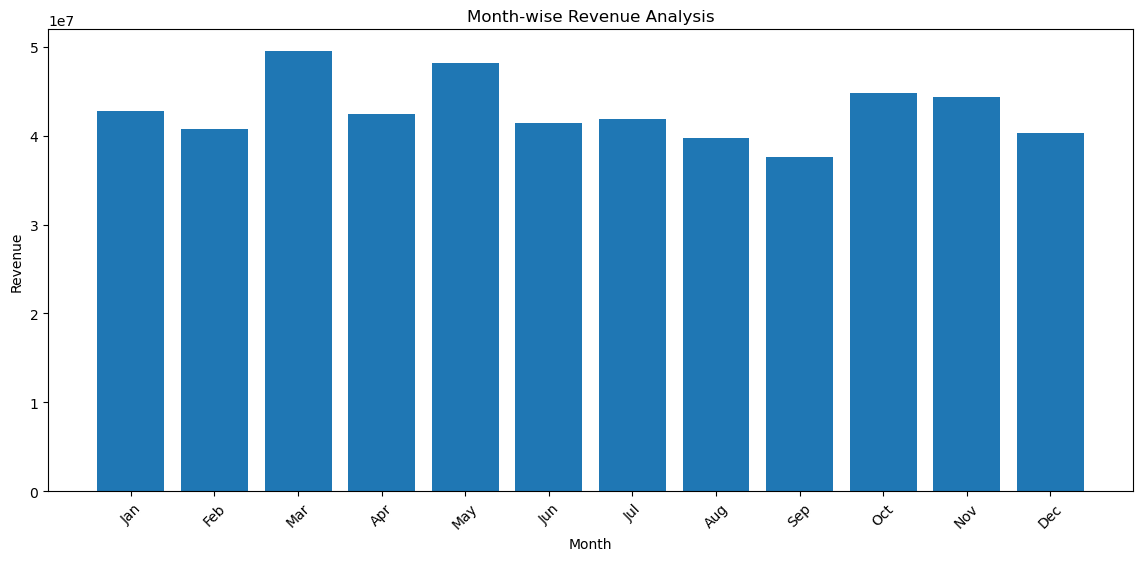

In [27]:
plt.figure(figsize=(14,6))

plt.bar(
    monthly_sales['month_name'],
    monthly_sales['total_amount']
)

plt.title("Month-wise Revenue Analysis")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

### ⭐ Observation
##### 1. Revenue peaks in March and May
##### 2. Sales dip significantly in September
##### 3. Seasonal fluctuations are visible
### ⭐ Business Recommendation
##### 1. Analyze successful March campaigns
##### 2. Introduce targeted offers during low-demand months
##### 3. Optimize seasonal inventory planning

## Question 2 : Year-over-Year Revenue Comparison

In [29]:
df['year'] = df['order_date'].dt.year
yearly_sales = df.groupby('year')['total_amount'].sum().reset_index()
yearly_sales = yearly_sales.sort_values('total_amount',ascending = False)
print(yearly_sales.to_string(index = False))


 year  total_amount
 2023     134276946
 2021     127404304
 2022     127348941
 2024     124513640


## Question 3 : Which payment methods are preferred?

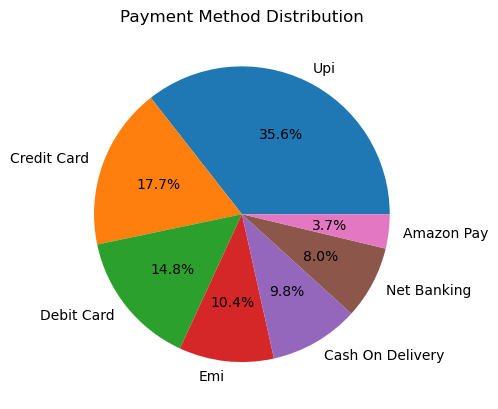

In [35]:
payment_dist = df['payment_method'].value_counts()

payment_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

# ⭐ Observation

##### 1.  Payment behavior reflects customer trust and regional digital adoption.

# ⭐ Recommendation
##### 1. Push cashback offers on dominant payment methods
##### 2. Improve checkout optimization

## Question 4 : Prime vs Non-Prime Customer Revenue Comparison

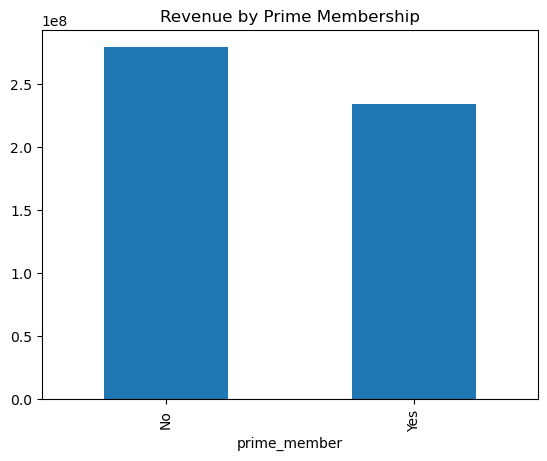

In [36]:
prime_sales = df.groupby('prime_member')['total_amount'].sum()

prime_sales.plot(kind='bar')
plt.title("Revenue by Prime Membership")
plt.show()

## Question 5 : Delivery Performance Analysis

In [38]:
df['delivery_days'].describe()

count    6186.000000
mean        4.513902
std         1.714143
min         2.000000
25%         3.000000
50%         4.000000
75%         6.000000
max         7.000000
Name: delivery_days, dtype: float64

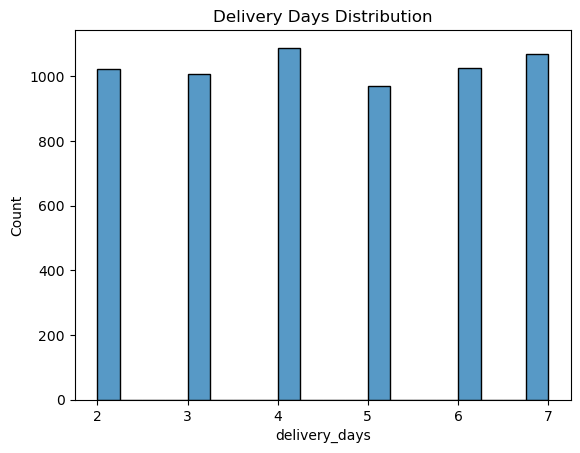

In [39]:
sns.histplot(df['delivery_days'], bins=20)
plt.title("Delivery Days Distribution")
plt.show()

### ⭐ Observation
##### 1. Delivery performance is reasonably efficient
##### 2. Logistics system is stable
### ⭐ Recommendation
##### 1. Reduce average delivery time below 4 days
##### 2. Improve fulfillment center allocation

## Question 6 : Which shipping methods are fastest?

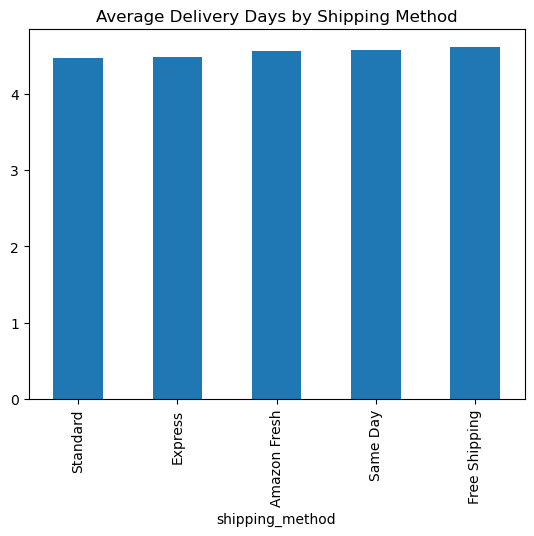

In [40]:
shipping_perf = df.groupby('shipping_method')['delivery_days'].mean().sort_values()

shipping_perf.plot(kind='bar')
plt.title("Average Delivery Days by Shipping Method")
plt.show()

## ⭐ Observation
#### 1. Delivery performance is reasonably efficient
#### 2. Logistics system is stable
## ⭐ Recommendation
#### 1. Reduce average delivery time below 4 days
#### 2. Improve fulfillment center allocation

## Question 7 : Order Status Health Analysis

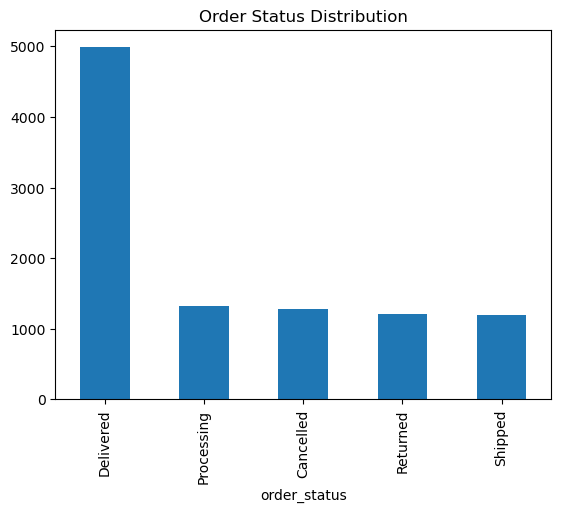

In [43]:
df['order_status'].value_counts().plot(kind='bar')
plt.title("Order Status Distribution")
plt.show()

## Question 8 : Top 10 Best-Selling Products

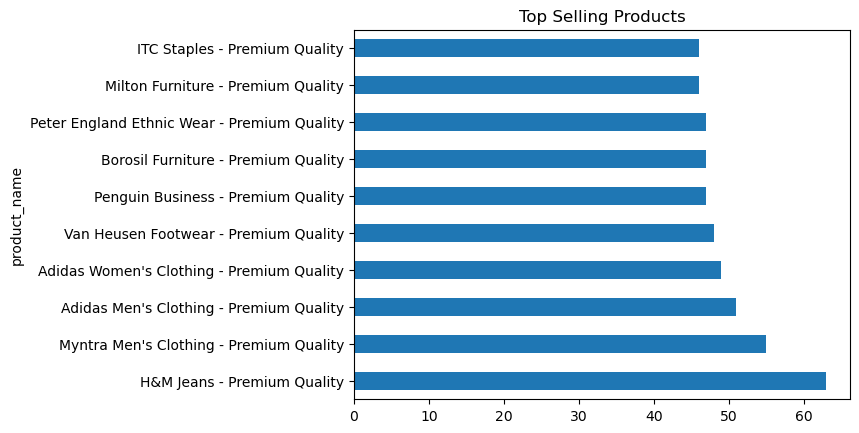

In [44]:
top_products = df.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh')
plt.title("Top Selling Products")
plt.show()

## Question 9 : Which cities generate the highest Average Order Value?

In [45]:
city_aov = df.groupby('city')['total_amount'].mean().sort_values(ascending=False).head(10)

print(city_aov)

city
Coimbatore    62721.113537
Faridabad     61920.145228
Kochi         60239.381743
Hubballi      59883.273973
Ranchi        59880.078512
Patna         59716.373913
New Delhi     59490.984375
Warangal      59077.974138
Hyderabad     57930.758621
Kolkata       57528.197761
Name: total_amount, dtype: float64


## Question 10 : Top Three Best Selling Categories

In [67]:
cat_Sales = df.groupby('category')['total_amount'].sum().reset_index()
cat_sales = cat_Sales.sort_values('total_amount',ascending = False)
cat_sales = cat_sales.reset_index(drop = True)
cat_sales.index = cat_sales.index+1
print(cat_sales.head(3))

         category  total_amount
1     Electronics     321342596
2  Home & Kitchen      84395676
3         Fashion      28858237


## ⭐ Observation
#### 1. Electronics dominates overall sales
#### 2. Revenue is highly concentrated in a few categories
#### 3. Home & Kitchen is a strong secondary segment
## ⭐ Recommendation
#### 1. Increase inventory allocation for Electronics
#### 2. Introduce bundle offers
#### 3. Expand product assortment in Home & Kitchen

## Question 11 : Bottom Three Category Based on Sales

In [68]:
cat_Sales = df.groupby('category')['total_amount'].sum().reset_index()
cat_sales = cat_Sales.sort_values('total_amount',ascending = False)
cat_sales = cat_sales.reset_index(drop = True)
cat_sales.index = cat_sales.index+1
print(cat_sales.tail(3))

                  category  total_amount
8   Beauty & Personal Care       6686115
9                    Books       3423865
10          Grocery & Food       3374953


## ⭐ Observation
#### 1. These categories contribute minimally  
#### 2. Product demand may be weak or under-promoted
## Recommendation
#### 1. Run category-specific promotions
#### 2. Reassess pricing strategy
#### 3. Improve product visibility

## Question 12 : Sales Based on Shipping Methods

In [69]:
ship_sales = df.groupby('shipping_method')['total_amount'].sum().reset_index()
ship_sales = ship_sales.sort_values('total_amount',ascending = False)
print(ship_sales.to_string(index = False))

shipping_method  total_amount
       Standard     209648235
        Express     130478843
  Free Shipping     101407059
       Same Day      50721270
   Amazon Fresh      21288424


### ⭐ Observation
#### Standard shipping contributes the majority of sales. 
### ⭐ Recommendation
#### 1. Optimize delivery route efficiency
#### 2. Offer premium shipping upsells

## Question 13 : Top perfroming City

In [48]:
city_Sales = df.groupby('city')['total_amount'].sum().reset_index()
city_Sales = city_Sales.sort_values('total_amount',ascending = False)
city_Sales = city_Sales.reset_index(drop = True)
city_Sales.index = city_Sales.index+1
print(city_Sales.head(5))

         city  total_amount
1     Kolkata      15417557
2   Faridabad      14922755
3       Kochi      14517691
4      Ranchi      14490979
5  Coimbatore      14363135


### ⭐ Observation
1. Metropolitan and rapidly growing cities drive strong revenue
2. Kolkata is the highest-performing city
### ⭐ Recommendation
1. Hyperlocal promotions in top cities
2. Faster delivery options in high-demand urban areas

## Question 14 : What is total business performance?

In [16]:
total_orders = df['order_id'].nunique()
total_revenue = df['total_amount'].sum()
avg_order_value = df['total_amount'].mean()
total_customers = df['customer_id'].nunique()

print(f"Total Orders: {total_orders}")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Average Order Value: ₹{avg_order_value:,.2f}")
print(f"Unique Customers: {total_customers}")

Total Orders: 10000
Total Revenue: ₹513,543,831.00
Average Order Value: ₹51,354.38
Unique Customers: 9958


## Question 15 : Which states generate highest revenue?

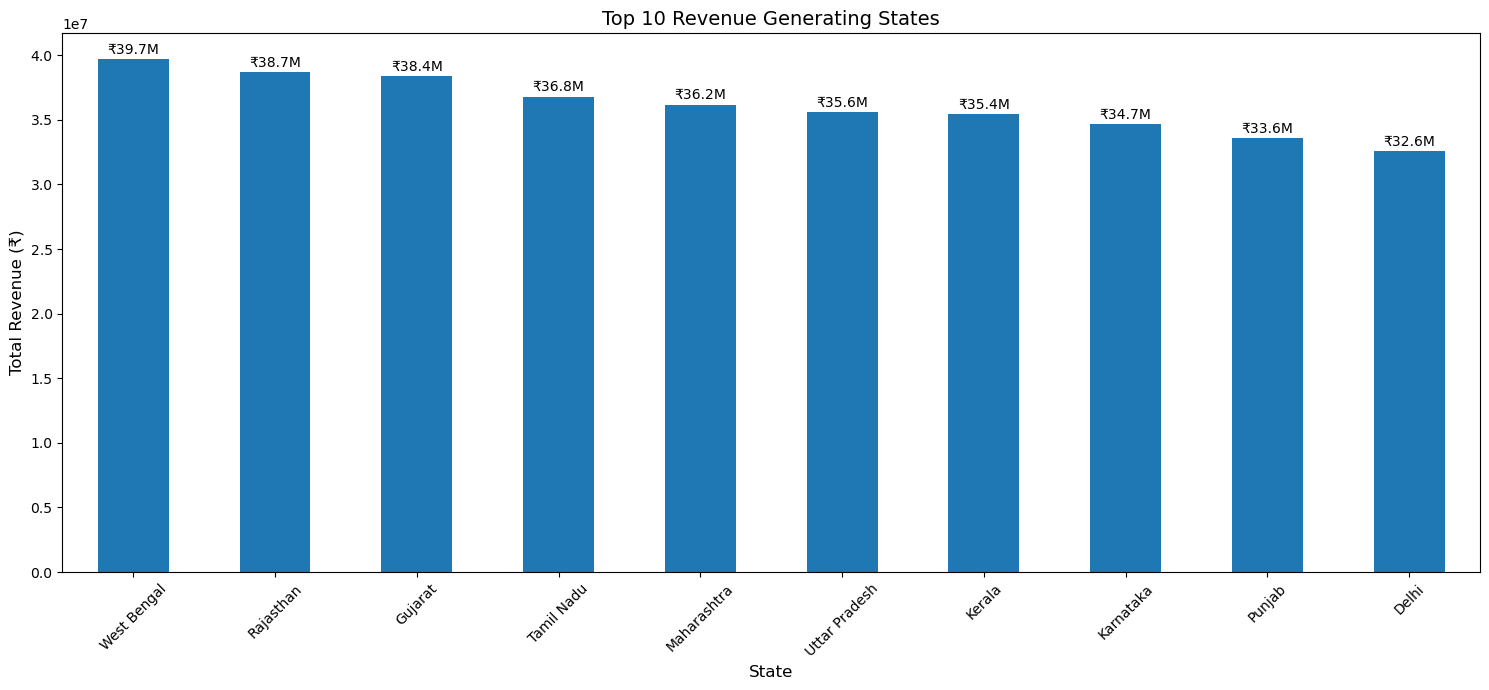

In [8]:
state_sales = df.groupby('state')['total_amount'].sum().sort_values(ascending=False)

top_states = state_sales.head(10)

plt.figure(figsize=(15,7))
ax = top_states.plot(kind='bar')

plt.title("Top 10 Revenue Generating States", fontsize=14)
plt.xlabel("State", fontsize=12)
plt.ylabel("Total Revenue (₹)", fontsize=12)
plt.xticks(rotation=45)


for i, value in enumerate(top_states):
    plt.text(
        i,
        value + (top_states.max()*0.01),
        f'₹{value/1e6:.1f}M',
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Question 17 : Which product categories drive maximum sales?

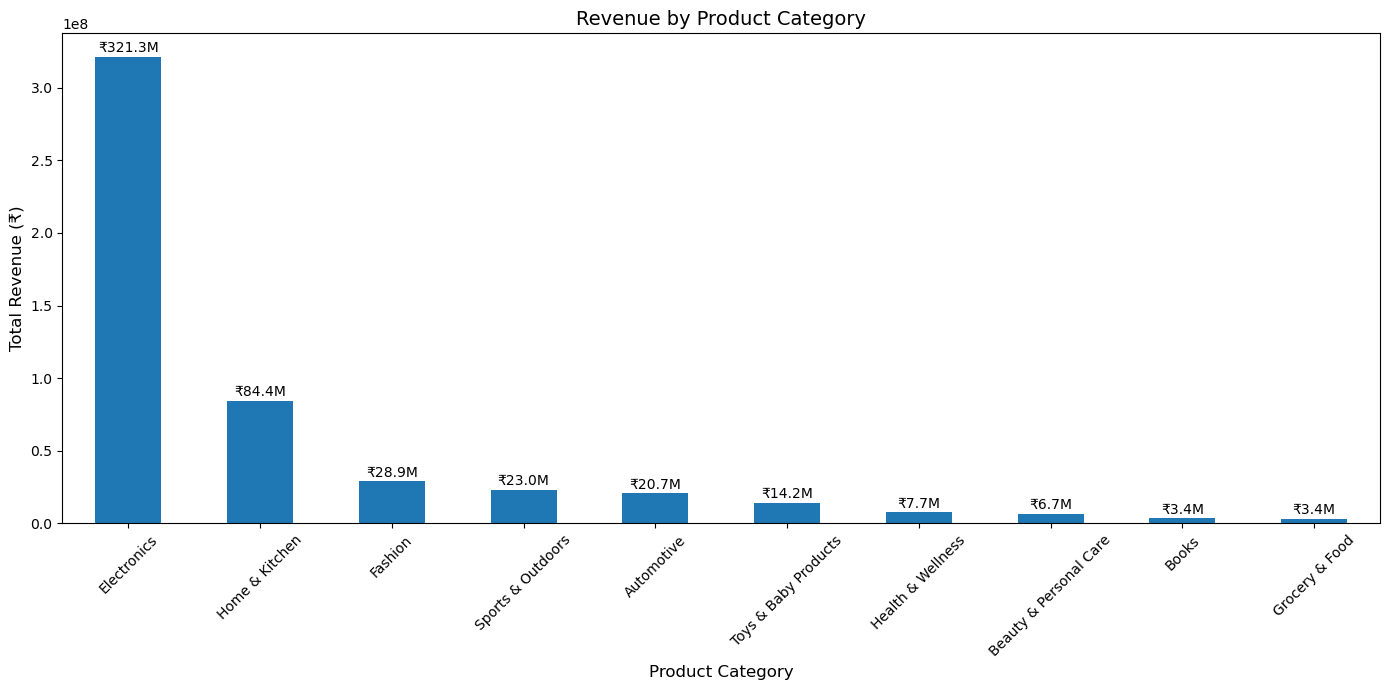

In [6]:
category_sales = df.groupby('category')['total_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(14,7))
ax = category_sales.plot(kind='bar')

plt.title("Revenue by Product Category", fontsize=14)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Total Revenue (₹)", fontsize=12)
plt.xticks(rotation=45)

for i, value in enumerate(category_sales):
    plt.text(
        i,
        value + (category_sales.max()*0.01),
        f'₹{value/1e6:.1f}M',
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

# Customer Behavior Analysis

## Question 18 : What products receive highest customer satisfaction?

In [10]:
top_rated = df.groupby('product_name')['product_rating'].mean().sort_values(ascending=False).head(10)

print(top_rated)

product_name
Vector X Professional Wok (Kashmir Willow)                     5.0
Baidyanath Conditioner for Muscle Gain                         5.0
Fabindia Printed Georgette Saree (Black)                       5.0
Lakme Sunscreen for Normal Skin (50ml)                         5.0
Lakme Moisturizer Cream/Gel (150ml)                            5.0
LG Slim Plus Laptop (Intel i7, 16GB RAM, 64GB SSD, 14" FHD)    5.0
Asus Note 50 5G (8GB RAM, 64GB, Graphite)                      5.0
The God of Small Things (Paperback) by Jhumpa Lahiri           5.0
River of Fire - Romance Novel by Ruskin Bond                   5.0
WOW Toner Cream/Gel (200ml)                                    5.0
Name: product_rating, dtype: float64


## Question 19 : Customer Repeat Purchase Behavior

In [9]:
repeat_customers = df.groupby('customer_id')['order_id'].count()

repeat_rate = (repeat_customers > 1).mean() * 100

print(f"Repeat Customer Rate: {repeat_rate:.2f}%")

Repeat Customer Rate: 0.42%


## Question 20 : Which customer segment spends the most?

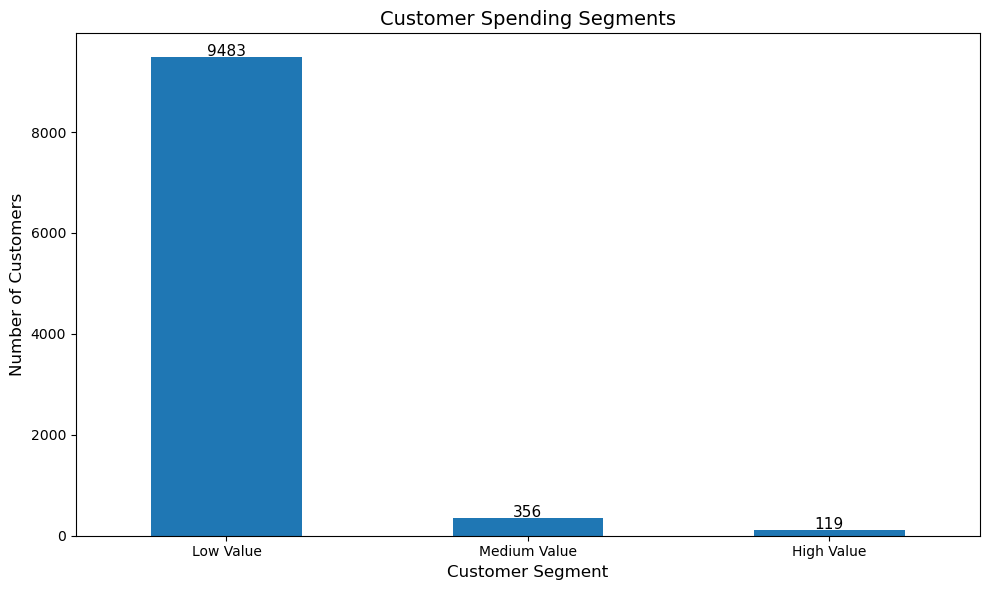

In [4]:
customer_spending = df.groupby('customer_id')['total_amount'].sum()

customer_segments = pd.cut(
    customer_spending,
    bins=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

segment_counts = customer_segments.value_counts()

plt.figure(figsize=(10,6))
ax = segment_counts.plot(kind='bar')

plt.title("Customer Spending Segments", fontsize=14)
plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.xticks(rotation=0)

# Add values above bars
for i, value in enumerate(segment_counts):
    plt.text(i, value + 20, str(value),
             ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## Question 21 : Which cities show highest repeat customer activity?

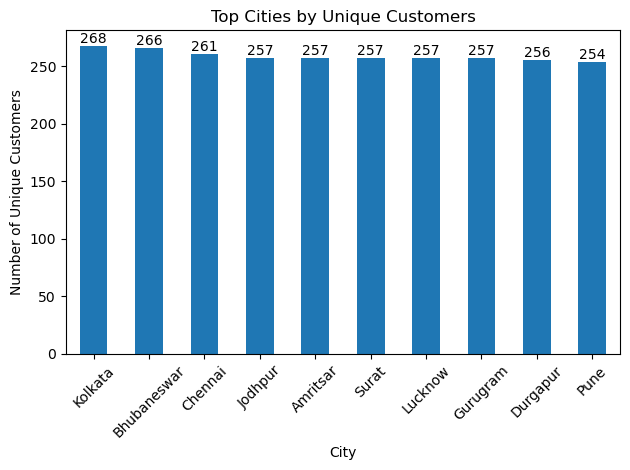

In [6]:
city_loyalty = df.groupby('city')['customer_id'].nunique().sort_values(ascending=False).head(10)

ax = city_loyalty.plot(kind='bar')

plt.title("Top Cities by Unique Customers")
plt.xlabel("City")
plt.ylabel("Number of Unique Customers")
plt.xticks(rotation=45)


for i in ax.containers:
    ax.bar_label(i)

plt.tight_layout()
plt.show()

## Question 22 : Do customer ratings influence buying behavior?

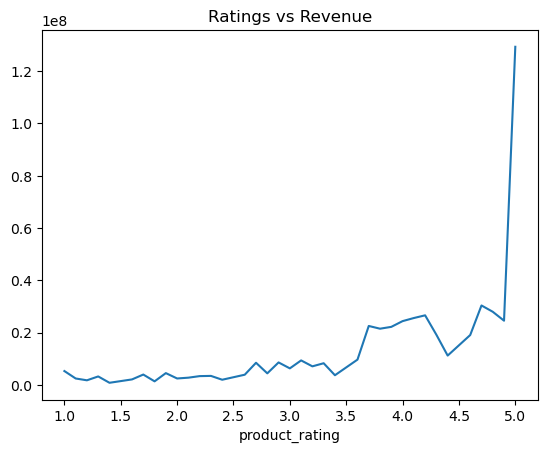

In [7]:
rating_sales = df.groupby('product_rating')['total_amount'].sum()

rating_sales.plot(kind='line')
plt.title("Ratings vs Revenue")
plt.show()

## Question 23 : How frequently do customers cancel orders? 

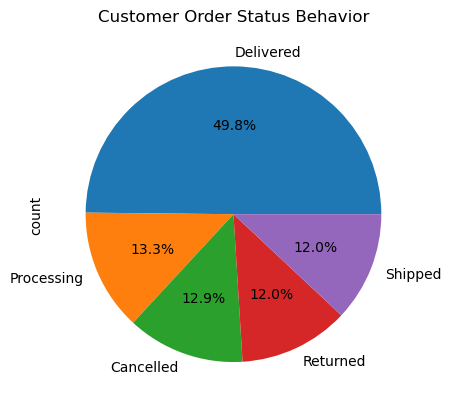

In [23]:
df['order_status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Customer Order Status Behavior")
plt.show()

# Summary

In [47]:
print("="*50)
print(" AMAZON INDIA SALES KPI DASHBOARD ")
print("="*50)

print(f"Total Revenue: ₹{df['total_amount'].sum():,.2f}")
print(f"Total Orders: {df['order_id'].nunique():,}")
print(f"Unique Customers: {df['customer_id'].nunique():,}")
print(f"Average Order Value: ₹{df['total_amount'].mean():.2f}")
print(f"Average Discount: {df['discount_percent'].mean():.2f}%")
print(f"Average Delivery Days: {df['delivery_days'].mean():.2f}")
print(f"Average Product Rating: {df['product_rating'].mean():.2f}")
print(f"Repeat Customer Rate: {repeat_rate:.2f}%")
print(f"Prime Revenue Contribution: {(df[df['prime_member']=='Yes']['total_amount'].sum()/df['total_amount'].sum())*100:.2f}%")

 AMAZON INDIA SALES KPI DASHBOARD 
Total Revenue: ₹513,543,831.00
Total Orders: 10,000
Unique Customers: 9,958
Average Order Value: ₹51354.38
Average Discount: 24.59%
Average Delivery Days: 4.51
Average Product Rating: 4.11
Repeat Customer Rate: 0.42%
Prime Revenue Contribution: 45.63%
